## 설치

현재 main 기준 설치 예시입니다.

```bash
uv add git+https://github.com/CGINSIDE-ROOKIES/document-processor
# 또는 로컬 체크아웃에서:
uv pip install -e .
```

In [1]:
from document_processor import DocIR
from pprint import pprint

pprint(DocIR.model_fields)

{'assets': FieldInfo(annotation=dict[str, ImageAsset], required=False, default_factory=dict),
 'doc_id': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'identity_version': FieldInfo(annotation=int, required=False, default=1),
 'meta': FieldInfo(annotation=Union[TypeVar, NoneType], required=False, default=None),
 'pages': FieldInfo(annotation=list[PageInfo], required=False, default_factory=list),
 'paragraphs': FieldInfo(annotation=list[ParagraphIR], required=False, default_factory=list),
 'source_doc_type': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'source_path': FieldInfo(annotation=Union[str, NoneType], required=False, default=None)}


- `identity_version`: 현 미사용 (versioning이나 스키마 버전용)
- `meta`: 필요한 메타데이터 있을 경우 여기다 원하는 데이터 추가 가능 (DataFrame 상속 obj)

In [2]:
from pathlib import Path

DOC_DIR = Path("doc_samples/new_test/")

# 예시
FP = DOC_DIR / "01. 대중문화예술분야 연습생 표준계약서.hwpx"
# FP = DOC_DIR / "style_test_sample.docx"

doc = DocIR.from_file(FP)

In [3]:
doc.source_doc_type, doc.source_path, doc.doc_id

('hwpx',
 'doc_samples/new_test/01. 대중문화예술분야 연습생 표준계약서.hwpx',
 '01. 대중문화예술분야 연습생 표준계약서')

각 페이지 정보

In [4]:
[pprint(page) for page in doc.pages]
print(len(doc.pages))

PageInfo(page_number=1, width_pt=595.28, height_pt=841.89, margin_left_pt=56.69, margin_right_pt=56.69, margin_top_pt=56.69, margin_bottom_pt=28.34)
PageInfo(page_number=2, width_pt=595.28, height_pt=841.89, margin_left_pt=56.69, margin_right_pt=56.69, margin_top_pt=56.69, margin_bottom_pt=28.34)
PageInfo(page_number=3, width_pt=595.28, height_pt=841.89, margin_left_pt=56.69, margin_right_pt=56.69, margin_top_pt=56.69, margin_bottom_pt=28.34)
PageInfo(page_number=4, width_pt=595.28, height_pt=841.89, margin_left_pt=56.69, margin_right_pt=56.69, margin_top_pt=56.69, margin_bottom_pt=28.34)
PageInfo(page_number=5, width_pt=595.28, height_pt=841.89, margin_left_pt=56.69, margin_right_pt=56.69, margin_top_pt=56.69, margin_bottom_pt=28.34)
PageInfo(page_number=6, width_pt=595.28, height_pt=841.89, margin_left_pt=56.69, margin_right_pt=56.69, margin_top_pt=56.69, margin_bottom_pt=28.34)
6


In [5]:
len(doc.paragraphs)

120

In [6]:
from document_processor import ImageIR, RunIR, TableIR

texts = []
for para in doc.paragraphs:
    for content in para.content:
        if isinstance(content, RunIR):
            texts.append((content.node_id, content.text))
        elif isinstance(content, ImageIR):
            texts.append((content.node_id, content.alt_text))
        elif isinstance(content, TableIR):
            texts.append((content.node_id, content.markdown))

for t in texts[:20]:
    print(f'{t[0]}: {t[1] if '\n' not in t[1] else '\n' + t[1]}')

r_f017369d1a2e2a89: 
r_3f1ff7241702452b: [별표1]
r_70a2dd7d5d150def: 대중문화예술분야 연습생 표준계약서
tbl_7f4ee182c8bb68ea: 
| col1 |
| --- |
| [image:img1] |
| 문화체육관광부고시<br><br>제2025-0069호 |
| (2026. 01. 01. 개정) |
r_78fae32810c3fd18: 
r_2f8086250aa9663b: [대중문화예술기획업자]                   (이하󰡐기획업자󰡑라 한다)[와, 과]
r_1e78227449d6e125: [연습생]                                 (이하󰡐연습생󰡑이라 한다)[는, 은] 
r_82e307e9c4ab3d8b: 
r_6fc704b50b41744e: 다음과 같이 연습생 계약을 체결함에 있어 상호 신의성실로써 이를 이행한다.
r_72baab1b94c69246: 
r_6d4357be1b51769b: 
r_1003cec539a3567e: 
r_cb98d2129c277174: 제1장 총 칙 
r_6c9a71e42264dc46: 
r_466de59813d9ae77: 제1조 (목적 및 정의) 
r_0fa888500ee596ad: ① 
r_221aaf34fc832eb6: 이 계약의 목적은 기획업자와 연습생이 상호 발전을 위해
r_8036eeb8ca5bf57b:  적극적으로 협력하는 것을 전제로, 기획업자는 연습생의 재능과 자질이 최대한 발휘될 수 있도록 훈련제공 등의 투자를 하며, 연습생은 기획업자가 제공하는 훈련 등에 충실히 임하고 자기개발을 위해 노력함으로써 상호 발전과 이익을 도모하는 데 있다.
r_5ed504e310f9d29a: ② 이 계약에서 “연습생”이란 대중문화예술용역을 제공할 의사를 가지고 대중문화예술인의 직업수행에 필요한 능력의 습득ㆍ향상을 목적으로 하는 훈련을 제공받기 위하여 기획업자와 계약을 체결하는 사람을 말한다.
r_0f275c4038f5ddad: 


In [7]:
sample = doc.paragraphs[0]

print(sample.model_dump_json(indent=2))

{
  "meta": null,
  "node_id": "p_bfa4da5a775f2ffd",
  "text": "[별표1]",
  "page_number": 1,
  "bbox": null,
  "para_style": {
    "align": "justify",
    "left_indent_pt": 0.0,
    "right_indent_pt": 0.0,
    "first_line_indent_pt": 0.0,
    "hanging_indent_pt": null,
    "render_tag": null,
    "column_layout": null,
    "list_info": null
  },
  "content": [
    {
      "meta": null,
      "node_id": "r_f017369d1a2e2a89",
      "text": "",
      "bbox": null,
      "run_style": {
        "font_family": null,
        "bold": true,
        "italic": false,
        "underline": false,
        "strikethrough": false,
        "superscript": false,
        "subscript": false,
        "color": null,
        "highlight": null,
        "size_pt": 15.0,
        "hidden": false
      },
      "native_anchor": {
        "source_doc_type": "hwpx",
        "node_kind": "run",
        "debug_path": "s1.p1.r1",
        "parent_debug_path": "s1.p1",
        "part_name": null,
        "structural_path"

In [8]:
sample.runs, sample.images

([RunIR(meta=None, node_id='r_f017369d1a2e2a89', text='', bbox=None, run_style=RunStyleInfo(font_family=None, bold=True, italic=False, underline=False, strikethrough=False, superscript=False, subscript=False, color=None, highlight=None, size_pt=15.0, hidden=False), native_anchor=NativeAnchor(source_doc_type='hwpx', node_kind='run', debug_path='s1.p1.r1', parent_debug_path='s1.p1', part_name=None, structural_path='s1.p1.r1', text_hash='da39a3ee5e6b4b0d3255bfef95601890afd80709')),
  RunIR(meta=None, node_id='r_3f1ff7241702452b', text='[별표1]', bbox=None, run_style=RunStyleInfo(font_family=None, bold=True, italic=False, underline=False, strikethrough=False, superscript=False, subscript=False, color=None, highlight=None, size_pt=15.0, hidden=False), native_anchor=NativeAnchor(source_doc_type='hwpx', node_kind='run', debug_path='s1.p1.r2', parent_debug_path='s1.p1', part_name=None, structural_path='s1.p1.r2', text_hash='8eba3ed12a3b89fed81a0580ea6380b29e3a38c5'))],
 [])

In [9]:
sample.para_style

ParaStyleInfo(align='justify', left_indent_pt=0.0, right_indent_pt=0.0, first_line_indent_pt=0.0, hanging_indent_pt=None, render_tag=None, column_layout=None, list_info=None)

표(table) 다루기

In [10]:
tables = [table for para in doc.paragraphs for table in para.tables]
len(tables), tables

(1,
 [TableIR(meta=None, node_id='tbl_7f4ee182c8bb68ea', row_count=3, col_count=1, bbox=None, table_style=TableStyleInfo(row_count=3, col_count=1, width_pt=111.13, height_pt=111.17, placement=None, render_grid=False), cells=[TableCellIR(meta=None, node_id='cell_cdc265cc1145293c', row_index=1, col_index=1, text='', bbox=None, cell_style=CellStyleInfo(background=None, vertical_align='center', horizontal_align=None, width_pt=111.13, height_pt=73.53, padding_top_pt=1.41, padding_right_pt=1.41, padding_bottom_pt=1.41, padding_left_pt=1.41, border_top=None, border_bottom=None, border_left=None, border_right=None, diagonal_tl_br=None, diagonal_tr_bl=None, rowspan=1, colspan=1), paragraphs=[ParagraphIR(meta=None, node_id='p_437fa4fefa393ccb', text='', page_number=1, bbox=None, para_style=ParaStyleInfo(align='center', left_indent_pt=0.0, right_indent_pt=0.0, first_line_indent_pt=0.0, hanging_indent_pt=None, render_tag=None, column_layout=None, list_info=None), content=[ImageIR(node_id='img_fffc

In [11]:
table = tables[0]
(table.row_count, table.col_count), \
    [(cell.row_index, cell.col_index, cell.node_id, cell.text) for cell in table.cells]

((3, 1),
 [(1, 1, 'cell_cdc265cc1145293c', ''),
  (2, 1, 'cell_c140d37cf7f53629', '문화체육관광부고시 \n제2025-0069호'),
  (3, 1, 'cell_7508e11eeef7e0ef', '(2026. 01. 01. 개정)')])

---

## HTML로 출력하기

In [12]:
html = doc.to_html(title="demo")

""
문화체육관광부고시 제2025-0069호
(2026. 01. 01. 개정)

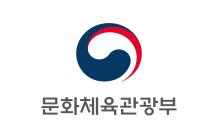

In [13]:
from IPython.core.display import HTML

def show_html(html: str) -> None:
	display(HTML(f"""
		<iframe srcdoc='{html}' width="100%" height="750px" style="border:none;"></iframe>
	"""))

show_html(html)

In [14]:
from random import randrange
from document_processor import render_review_html, DocumentInput, TextAnnotation

para_list = [para for para in doc.paragraphs]
run_list = [run for para in para_list for run in para.runs]

def get_rand_elem(ls: list):
    res = ls[randrange(len(ls))]
    while not res.text.strip():
        res = ls[randrange(len(ls))]
    return res

rand1 = get_rand_elem(run_list)
rand2 = get_rand_elem(run_list)
rand3 = get_rand_elem(para_list)

# cell만 다루기 - 예시용 셀 
rand4 = [ cell 
	for para in doc.paragraphs 
		for table in para.tables
			for cell in table.cells
][1]

doc_input = DocumentInput(doc_ir=doc)

In [15]:
annotated_result = render_review_html(
	document=doc_input,
	annotations=[
		TextAnnotation(
			target_kind="run",  # AnnotationTargetKind = Literal["paragraph", "run"]
            target_id=rand1.node_id,
            selected_text=rand1.text,
            occurrence_index=0,
            label="match",
            color="#727cff"
		),
		TextAnnotation(
			target_kind="run",
			target_id=rand2.node_id,
			selected_text=rand2.text,
			occurrence_index=0,
			label="match",
			color="#ff6e6e"
		),
		TextAnnotation(
			target_kind="paragraph",
			target_id=rand3.node_id,
			selected_text=rand3.text,
			occurrence_index=0,
			label="하늘샛 하이라이팅!",
			color="#6effd8"
		)
	]
)

f'result validation ok?: {annotated_result.ok}', \
    (rand1.node_id, rand1.text), (rand2.node_id, rand2.text), (rand3.node_id, rand3.text)

('result validation ok?: True',
 ('r_46a47b60507779aa',
  '                        계약체결 일시 :        년      월      일      '),
 ('r_31931c27aa019718', '                        계약체결 장소 :'),
 ('p_42a487764ef08d98',
  '⑤ 기획업자는 연습생의 사전 서면동의를 얻은 후 이 계약상 권리 또는 지위의 전부 또는 일부를 제3자에게 양도할 수 있다.'))

""
문화체육관광부고시 제2025-0069호
(2026. 01. 01. 개정)

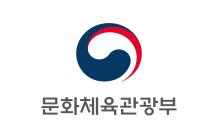

In [16]:
show_html(annotated_result.html)

## 문서 수정하기

In [17]:
from document_processor import apply_document_edits, TextEdit

assert rand4.node_id  # 린터 경고 없에기

edited_result = apply_document_edits(
	document=doc_input,
	edits=[
		TextEdit(
            target_kind="run",  # Literal["paragraph", "run", "cell"]
            target_id=rand1.node_id,
            expected_text=rand1.text,
            new_text="Hello Legal World",
            reason="Expand wording",
        ),
		TextEdit(
            target_kind="paragraph",
            target_id=rand3.node_id,
            expected_text=rand3.text,
            new_text="Hello Legal World",
            reason="Expand wording",
        ),
		TextEdit(
            target_kind="cell",
            target_id=rand4.node_id,
            expected_text=rand4.text,
            new_text="Hello Legal World",
            reason="Expand wording",
        ),
	],
 	return_doc_ir=True
)

f'result validation ok?: {edited_result.ok}', \
    (rand1.node_id, rand1.text), (rand3.node_id, rand3.text), (rand4.node_id, rand4.text)

('result validation ok?: False',
 ('r_46a47b60507779aa',
  '                        계약체결 일시 :        년      월      일      '),
 ('p_42a487764ef08d98',
  '⑤ 기획업자는 연습생의 사전 서면동의를 얻은 후 이 계약상 권리 또는 지위의 전부 또는 일부를 제3자에게 양도할 수 있다.'),
 ('cell_c140d37cf7f53629', '문화체육관광부고시 \n제2025-0069호'))

위처럼 `edited_result.ok`가 False인 경우 exception 처리가 안나오게 설계됨, `.validation.issues`통해서 오류 확인 가능. -> langrgaph/langchain/pydanticAI 처리위함

(파일에 따라 위 예시에서 오류 안나올수도)

In [18]:
edited_result.validation.issues

[EditValidationIssue(code='invalid_operation', target_kind=None, target_id=None, operation=None, message='Cell text replacement for cell_c140d37cf7f53629 must preserve paragraph count: expected 2 line(s), got 1.', expected_text=None, current_text=None)]

수정 결과 객체 구조:

In [19]:
from document_processor import ApplyDocumentEditsResult
ApplyDocumentEditsResult.model_fields

{'ok': FieldInfo(annotation=bool, required=False, default=True),
 'source_doc_type': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'source_name': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'output_path': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'output_filename': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'output_bytes': FieldInfo(annotation=Union[bytes, NoneType], required=False, default=None),
 'updated_doc_ir': FieldInfo(annotation=Union[DocIR, NoneType], required=False, default=None),
 'edits_applied': FieldInfo(annotation=int, required=False, default=0),
 'operations_applied': FieldInfo(annotation=int, required=False, default=0),
 'styles_applied': FieldInfo(annotation=int, required=False, default=0),
 'modified_target_ids': FieldInfo(annotation=list[str], required=False, default_factory=list),
 'created_target_ids': FieldInfo(annotation=list[str], require

In [20]:
from document_processor import EditValidationIssue
EditValidationIssue.model_fields

{'code': FieldInfo(annotation=Literal['target_not_found', 'target_kind_mismatch', 'text_mismatch', 'mixed_content_not_supported', 'paragraph_count_mismatch', 'invalid_operation', 'invalid_position', 'invalid_table_shape', 'index_out_of_bounds', 'unsupported_source_doc_type', 'output_path_conflicts_with_source', 'native_source_required', 'invalid_style'], required=True),
 'target_kind': FieldInfo(annotation=Union[Literal['paragraph', 'run', 'cell', 'table', 'image'], NoneType], required=False, default=None),
 'target_id': FieldInfo(annotation=Union[str, NoneType], required=False, default=None),
 'operation': FieldInfo(annotation=Union[Literal['insert_paragraph', 'remove_paragraph', 'insert_run', 'remove_run', 'insert_table', 'remove_table', 'set_cell_text', 'insert_table_row', 'remove_table_row', 'insert_table_column', 'remove_table_column'], NoneType], required=False, default=None),
 'message': FieldInfo(annotation=str, required=True),
 'expected_text': FieldInfo(annotation=Union[str, 

오류문구:
```
Cell text replacement for cell_c140d37cf7f53629 must preserve paragraph count: expected 2 line(s), got 1.
```
> `\n` 통해 paragraph break인식 시키도록 하면 됨

In [21]:
edits1 = [
	TextEdit(
		target_kind="run",  # Literal["paragraph", "run", "cell"]
		target_id=rand1.node_id,
		expected_text=rand1.text,
		new_text=" Hello Legal World ",
		reason="Expand wording",
	),
	TextEdit(
		target_kind="paragraph",
		target_id=rand3.node_id,
		expected_text=rand3.text,
		new_text="\n[Paragraph replaced here!]\n",
		reason="Expand wording",
	),
	TextEdit(
		target_kind="cell",
		target_id=rand4.node_id,
		expected_text=rand4.text,
		new_text="Hello! \n Legal World",  # \n 통해서 paragraph 분리
		reason="Expand wording",
	),
]

edited_result = apply_document_edits(
	document=doc_input,
	edits=edits1,
 	return_doc_ir=True
)

f'result validation ok?: {edited_result.ok} | {edited_result.validation.issues}', \
    (rand1.node_id, rand1.text), (rand3.node_id, rand3.text), (rand4.node_id, rand4.text)

('result validation ok?: True | []',
 ('r_46a47b60507779aa',
  '                        계약체결 일시 :        년      월      일      '),
 ('p_42a487764ef08d98',
  '⑤ 기획업자는 연습생의 사전 서면동의를 얻은 후 이 계약상 권리 또는 지위의 전부 또는 일부를 제3자에게 양도할 수 있다.'),
 ('cell_c140d37cf7f53629', '문화체육관광부고시 \n제2025-0069호'))

""
Hello! Legal World
(2026. 01. 01. 개정)

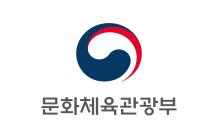

In [22]:
show_html(edited_result.updated_doc_ir.to_html())

stateless API이므로 수정된거로 input 객체 변경

In [23]:
doc_input  = DocumentInput(doc_ir=edited_result.updated_doc_ir)

In [24]:
from document_processor import StructuralEdit
assert rand4.node_id  # 린터 경고 없에기

'''
operation 종류들
Literal[
    "insert_paragraph",
    "remove_paragraph",
    "insert_run",
    "remove_run",
    "insert_table",
    "remove_table",
    "set_cell_text",
    "insert_table_row",
    "remove_table_row",
    "insert_table_column",
    "remove_table_column",
]
'''

struct_edit_result = apply_document_edits(
	document=doc_input,
	edits=[
		StructuralEdit(
			operation="insert_paragraph",
			target_id=rand3.node_id,
			position="before",
			text="paragraph 추가된거임!!!!!"
		),
		StructuralEdit(
			operation="insert_paragraph",
			target_id=rand3.node_id,
			position="after",
			text="paragraph 추가된거임!!!!!"
		),
		StructuralEdit(
			operation="insert_table_row",
			target_id=rand4.node_id,  # cell id 기준으로 행 작업 수행함
			position="after",
			values=['행 추가된겨']
		),
		StructuralEdit(
			operation="insert_table_column",
			target_id=rand4.node_id,  # cell id 기준으로 렬 작업 수행함
			position="after",
			values=['1','2','3','4',]
		),
	],
 	return_doc_ir=True
)

f'result validation ok?: {struct_edit_result.ok}', \
    (rand3.node_id, rand1.text), (rand3.node_id, rand3.text)

('result validation ok?: True',
 ('p_42a487764ef08d98',
  '                        계약체결 일시 :        년      월      일      '),
 ('p_42a487764ef08d98',
  '⑤ 기획업자는 연습생의 사전 서면동의를 얻은 후 이 계약상 권리 또는 지위의 전부 또는 일부를 제3자에게 양도할 수 있다.'))

In [25]:
struct_edit_result.created_target_ids

['p_5459f952bf908b7a',
 'r_8128c8fe54291834',
 'p_85137b4f37f13d0a',
 'r_4f69ababdfa8ec43',
 'cell_fc8eb1446238dbcb',
 'p_a23bd0e8e4d8f944',
 'r_f21c4aeebf725b81',
 'cell_4b917acab9cab0ef',
 'p_dd5e94aad236a054',
 'r_51a45f8bdec5229f',
 'cell_fdac8cbb7ee67870',
 'p_49f48ebb85330c7b',
 'r_678283d4b3c1a427',
 'cell_c893968cb0bef60c',
 'p_595cea6b8d30cce8',
 'r_085453130ffd251b',
 'cell_f893607580e04ab8',
 'p_ac29a1a8bcc561ff',
 'r_d70fb7e2863f58ad']

**연달아 추가된 작업의 경우에는 순차적으로 진행**

,1
Hello! Legal World,2
행 추가된겨,3
(2026. 01. 01. 개정),4

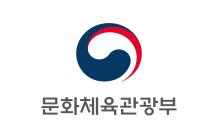

In [26]:
show_html(struct_edit_result.updated_doc_ir.to_html())

## 복합 작업 + 스타일 수정

In [27]:
from document_processor import StyleEdit
assert rand4.node_id  # 린터 경고 없에기

edits2 = [
	StructuralEdit(
		operation="insert_paragraph",
		target_id=rand3.node_id,
		position="before",
		text="paragraph 추가된거임!!!!!"
	),
	StructuralEdit(
		operation="insert_paragraph",
		target_id=rand3.node_id,
		position="after",
		text="paragraph 추가된거임!!!!!"
	),
	StructuralEdit(
		operation="insert_table_row",
		target_id=rand4.node_id,  # cell id 기준으로 행 작업 수행함
		position="after",
		values=['행 추가된겨']
	),
	TextEdit(
		target_kind="paragraph",
		target_id=rand3.node_id,
		expected_text="\n[Paragraph replaced here!]\n",
		new_text="이제 여기 색갈도 바뀜",
		reason="Expand wording",
	),
	StructuralEdit(
		operation="insert_table_column",
		target_id=rand4.node_id,  # cell id 기준으로 열 작업 수행함
		position="after",
		values=['1','2','3','4',]
	),
	StyleEdit(
		target_kind="run",  # Literal["paragraph", "run", "cell", "table", "image"]
		target_id=rand3.runs[0].node_id,
		bold=True,
		color="#4C3EB8",
		font_size_pt=32,
	),
	*[  # list unpacking 통해서 안에 여러개 동시 주입 가능!!
		StyleEdit(
			target_kind="run",
			target_id=run.node_id,
			color="#FFFFFF",
		)
		for para in rand4.paragraphs for run in para.runs
	],
	*[
		StyleEdit(
			target_kind="paragraph",
			target_id=para.node_id,
			paragraph_align="right"  # 여기 주목! ↓
		)
		for para in rand4.paragraphs
	],
	StyleEdit(
		target_kind="cell",
		target_id=rand4.node_id,
		background="#600B4F",
		padding_left_pt=10,
		padding_right_pt=10,
		height_pt=100,
		width_pt=200,
		horizontal_align="left",    # 여기 주목! ↑
		vertical_align="bottom",
		border_top="5pt single #000000",
		border_right="5pt single #000000",
		border_bottom="5pt single #000000",
		border_left="5pt single #000000",
	),
]

total_edit_result = apply_document_edits(
	document=doc_input,
	edits=edits2,
	return_doc_ir=True,
)

f'result validation ok?: {total_edit_result.ok}', \
    rand4.node_id

('result validation ok?: True', 'cell_c140d37cf7f53629')

~~렌더링 우선순위 때문에 cell "horizontal_align" vs paragraph "paragraph_align" 둘이 뜨면 paragraph 렌더링이 우선순위를 가지게 됨, 다음 예시에서도 paragraph상에서 오른정렬한게 셀 단위 왼정렬한걸 이김~~


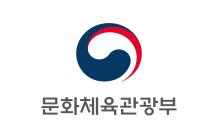

In [28]:
show_html(total_edit_result.updated_doc_ir.to_html(debug_layout=0))

**위 edits를 파일에 저장**

In [29]:
total_edit_result = apply_document_edits(
	document=DocumentInput(source_path=FP._str),
	edits=edits1 + edits2,
	return_doc_ir=True,
	output_filename='demo_result.hwpx'
)

print(f'result validation ok?: {total_edit_result.ok} | {total_edit_result.validation.issues}')

result validation ok?: True | []
